# Data pipeline

This notebook turns the raw dataset files into the train/val/test sets the model
actually trains on. Concretely it:

1. splits the official car IDs into train / validation / test
2. looks at a handful of raw cars, just to make sure the data looks right before
   building anything on top of it
3. loads every car, computes the features the model needs (normals, the Cd proxy),
   and caches the result so this doesn't have to be repeated
4. computes normalization statistics from the training set, and standardizes
   everything against those statistics


## Splitting the data

The dataset ships with `train.txt` and `test.txt`, but no validation split, so one is
carved out of the training IDs here (a fixed random 50, seeded for reproducibility).
Only 611 of the dataset's 798 cars are used at all — see the README for why the other
187 are excluded.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
from src.data import read_split, make_val_split
from src.dataset import build_all, compute_train_stats, to_pyg_data

train_ids_full = read_split("train.txt")
test_ids = read_split("test.txt")
train_ids, val_ids = make_val_split(train_ids_full, n_val=50, seed=0)

print(len(train_ids), "train", len(val_ids), "val", len(test_ids), "test")
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids + val_ids) == set(train_ids_full)


450 train 50 val 111 test


## Look at the raw data before doing anything else

Render a handful of raw dataset samples colored by their ground-truth surface
pressure, straight off disk (before any caching/normalization) -- a basic sanity
check that the meshes and the `press[96:]` offset fix (see `src/data.py`) actually
line up before building anything downstream.


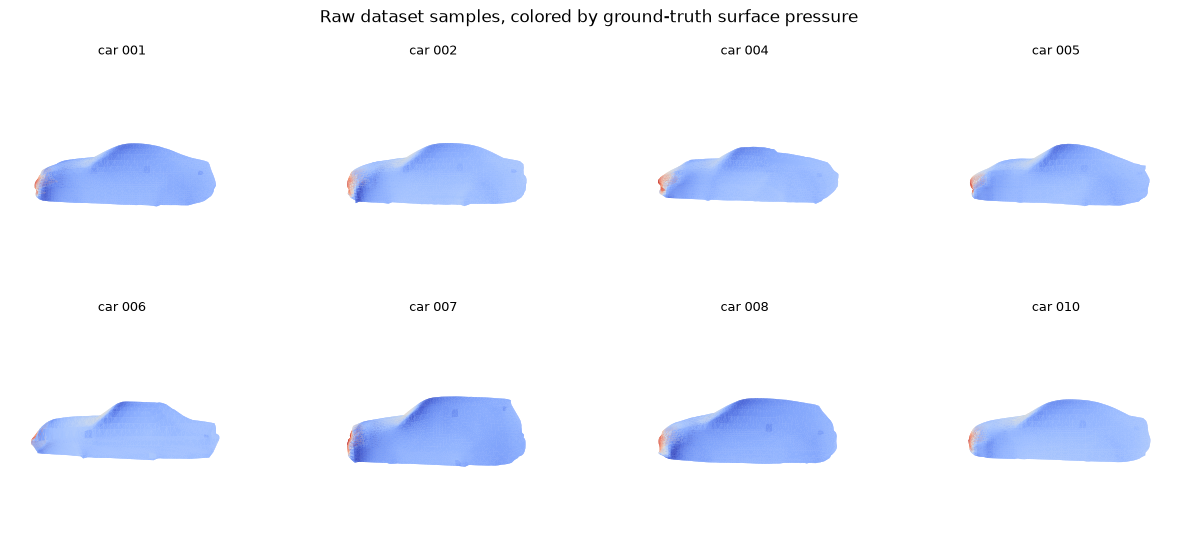

In [2]:
import os
from src.data import load_mesh, load_pressure, normalize_positions
from src import viz

os.makedirs("../outputs/figures", exist_ok=True)

preview_ids = train_ids_full[:8]
preview_samples = []
for sid in preview_ids:
    verts, faces = load_mesh(sid)
    pressure = load_pressure(sid, verts.shape[0])
    verts_norm, _, _ = normalize_positions(verts)
    preview_samples.append({"id": sid, "pos": verts_norm, "faces": faces, "pressure": pressure})

viz.render_sample_grid(preview_samples, save_path="../outputs/figures/raw_sample_grid.png")


## Building every car

Now the real work: for each of the 611 usable cars, load the mesh and pressure file,
compute per-vertex normals (not provided by the dataset), normalize the vertex
positions into a unit box, build the graph edges from the mesh's triangles, and
compute the Cd proxy from the pressure field. `build_all` caches the result to disk,
so re-running this notebook later just loads the cache instead of redoing all of this.


In [3]:
train_samples = build_all(train_ids, "train")
val_samples = build_all(val_ids, "val")
test_samples = build_all(test_ids, "test")


## Checking the numbers make sense

Before trusting any of this, a quick sanity check: pressure and vertex counts should
match for every car, and the pressure and Cd ranges should look like plausible
physical quantities rather than garbage. `CD_PHYSICAL_SIGN` here corrects the raw
formula's output to the physically meaningful (positive) sign — see the README for
how that sign was worked out.

`stats` (the mean/std used to standardize pressure and Cd for training) is computed
from the *training set only* — the validation and test sets should never influence
these numbers, or the model would be indirectly trained on information it shouldn't
have access to.


In [4]:
from src.shape_opt import CD_PHYSICAL_SIGN

for s in train_samples[:5]:
    assert s["pressure"].shape[0] == s["pos"].shape[0]

stats = compute_train_stats(train_samples)
print("train stats", stats)

all_pressure = np.concatenate([s["pressure"] for s in train_samples])
all_cd = CD_PHYSICAL_SIGN * np.array([s["cd"] for s in train_samples])
print("pressure min/mean/max", all_pressure.min(), all_pressure.mean(), all_pressure.max())
print("Cd (physical sign) min/mean/max", all_cd.min(), all_cd.mean(), all_cd.max())


train stats {'pressure_mean': -36.96725845336914, 'pressure_std': 47.97991943359375, 'cd_mean': -58.13138198852539, 'cd_std': 7.2842936515808105}
pressure min/mean/max -263.472 -36.96726 235.505
Cd (physical sign) min/mean/max 38.869892 58.131382 91.19522


A histogram view of the same thing: pressure across every vertex in the training set,
and Cd across the 450 training shapes.


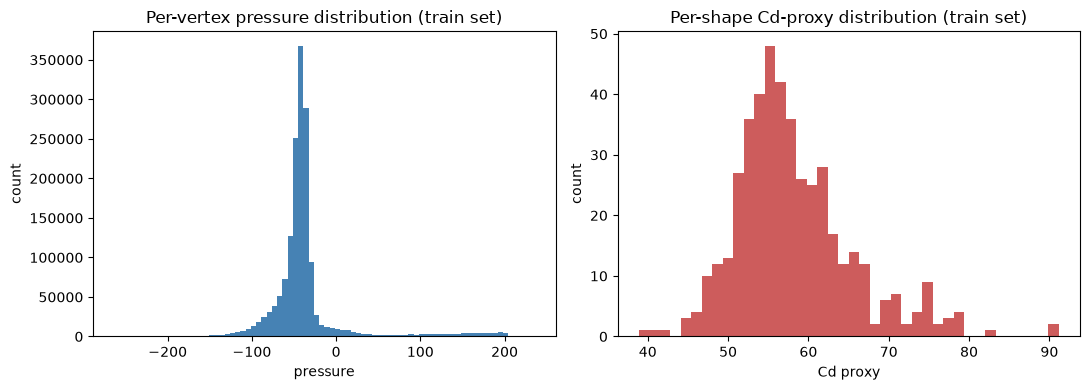

In [5]:
viz.plot_dataset_distributions(all_pressure, all_cd, save_path="../outputs/figures/dataset_distributions.png")


## Saving the normalization statistics

These are written to disk so every later notebook standardizes and de-standardizes
pressure and Cd the same way the training data did. This file matters more than it
looks — if it's ever recomputed from different data after the model has already been
trained, predictions from that model will silently be denormalized incorrectly.


In [6]:
import json, os
os.makedirs("../outputs", exist_ok=True)
with open("../outputs/norm_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
stats


{'pressure_mean': -36.96725845336914,
 'pressure_std': 47.97991943359375,
 'cd_mean': -58.13138198852539,
 'cd_std': 7.2842936515808105}

## Turning samples into graphs

Last step: standardize each car's pressure and Cd using the training statistics
above, and package everything into a PyTorch Geometric `Data` object — the format
the model and the training loop actually consume. These get cached too, so training
can start immediately next time without rebuilding anything.


In [7]:
train_data = [to_pyg_data(s, **stats) for s in train_samples]
val_data = [to_pyg_data(s, **stats) for s in val_samples]
test_data = [to_pyg_data(s, **stats) for s in test_samples]

import torch
torch.save(train_data, "../outputs/cache/train_pyg.pt")
torch.save(val_data, "../outputs/cache/val_pyg.pt")
torch.save(test_data, "../outputs/cache/test_pyg.pt")
print(train_data[0])


MeshData(x=[3586, 6], edge_index=[2, 21504], face=[3, 7168], face_batch=[7168], y_pressure=[3586], y_cd=[1], sample_id='465')
